# 🧭 OPERACIÓN CLUSTER — Misión de Análisis de Datos

---

> *"En algún lugar dentro de este caos de datos... se esconden patrones ocultos.
> Tu misión, si decides aceptarla, es encontrarlos."*

---

## 📋 Briefing de la Misión

Bienvenido/a, **Agente Analista** 🕵️

La **Agencia Internacional de Datos (AID)** ha recibido un conjunto de información sobre miles de clientes de una cadena de centros comerciales. Los datos están **sin etiquetar** — nadie sabe qué grupos existen, ni cuántos son.

Tu objetivo: **descubrir la estructura oculta** usando algoritmos de *clustering* (agrupamiento no supervisado).

### 🎯 Objetivos de la misión
1. ✅ Comprender qué es el clustering y para qué sirve
2. ✅ Aplicar **K-Means** y descubrir grupos de clientes
3. ✅ Usar **DBSCAN** para detectar anomalías
4. ✅ Visualizar los resultados como un/a verdadero/a analista
5. ✅ Completar el informe final de la misión

### ⚠️ Clasificación: NIVEL INTERMEDIO

---

## 🔐 FASE 0 — Preparar el equipo

Todo buen agente necesita sus herramientas. Ejecuta la siguiente celda para importar las **librerías** necesarias.

> 💡 **¿Qué estamos importando y por qué?**
> - `numpy` / `pandas`: para manejar los datos
> - `matplotlib` / `seaborn`: para visualizar los resultados
> - `sklearn`: la caja de herramientas de Machine Learning (aquí viven los algoritmos de clustering)
> - `warnings`: para silenciar avisos molestos que no nos afectan

In [ ]:
# 📦 CARGANDO ARSENAL DE HERRAMIENTAS...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Estilo visual de la misión 🎨
plt.style.use('dark_background')
sns.set_palette('bright')

print("✅ Arsenal cargado. Agente listo para la misión.")

---

## 📂 FASE 1 — Acceder a los archivos secretos

La AID ha interceptado un dataset de un **centro comercial**: contiene información sobre sus clientes.

Cada fila es un cliente. Las columnas que nos interesan son:

| Columna | Descripción |
|---|---|
| `CustomerID` | ID único del cliente |
| `Gender` | Género |
| `Age` | Edad (años) |
| `Annual Income (k$)` | Ingresos anuales en miles de dólares |
| `Spending Score (1-100)` | Puntuación de gasto asignada por el centro (1=bajo, 100=alto) |

> 🔍 **La pregunta clave:** ¿Existen grupos naturales de clientes? ¿Podría el centro comercial personalizar sus campañas de marketing para cada grupo?

Generaremos datos similares al famoso dataset "Mall Customers" para no depender de internet:

In [ ]:
# 🔧 Generamos datos realistas 

np.random.seed(42)  # semilla fija → resultados reproducibles

n = 400  # número de clientes

# --- Creamos 5 grupos "ocultos" con distintos perfiles ---
grupos_reales = {
    "Jóvenes gastadores":     {"edad": (20, 5),  "ingreso": (40, 8),  "gasto": (80, 10), "n": 80},
    "Adultos ahorradores":    {"edad": (45, 8),  "ingreso": (70, 10), "gasto": (20, 8),  "n": 80},
    "Alto poder adquisitivo": {"edad": (35, 7),  "ingreso": (100, 12),"gasto": (85, 8),  "n": 80},
    "Clase media moderada":   {"edad": (38, 10), "ingreso": (55, 10), "gasto": (50, 12), "n": 80},
    "Mayores conservadores":  {"edad": (60, 8),  "ingreso": (30, 8),  "gasto": (15, 7),  "n": 80},
}

filas = []
for nombre, params in grupos_reales.items():
    for _ in range(params["n"]):
        edad    = int(np.clip(np.random.normal(params["edad"][0],   params["edad"][1]),   18, 80))
        ingreso = int(np.clip(np.random.normal(params["ingreso"][0],params["ingreso"][1]),15, 140))
        gasto   = int(np.clip(np.random.normal(params["gasto"][0],  params["gasto"][1]),  1,  99))
        filas.append({"Edad": edad, "Ingresos_k$": ingreso, "Puntuacion_Gasto": gasto})

df = pd.DataFrame(filas)

# Añadimos unos pocos 'outliers' (datos raros) que DBSCAN detectará luego
outliers = pd.DataFrame([
    {"Edad": 22, "Ingresos_k$": 130, "Puntuacion_Gasto": 2},
    {"Edad": 75, "Ingresos_k$": 120, "Puntuacion_Gasto": 95},
    {"Edad": 19, "Ingresos_k$": 15,  "Puntuacion_Gasto": 98},
])
df = pd.concat([df, outliers], ignore_index=True)

print(f"📁 Archivo descifrado. Registros totales: {len(df)}")
print("\n🔎 Primeras 5 filas del dataset:")
df.head()

### 🧩 RETO 1 — Inspección inicial

> 📌 **Tu turno, Agente.** Antes de aplicar cualquier algoritmo, un buen analista siempre explora los datos. Responde estas preguntas ejecutando el código de abajo:

In [ ]:
# 🔍 Exploración básica — ¿Qué esconden los datos?
print("=" * 50)
print("📊 ESTADÍSTICAS BÁSICAS")
print("=" * 50)
print(df.describe().round(2))

print("\n" + "=" * 50)
print("🕳️ VALORES NULOS")
print("=" * 50)
print(df.isnull().sum())

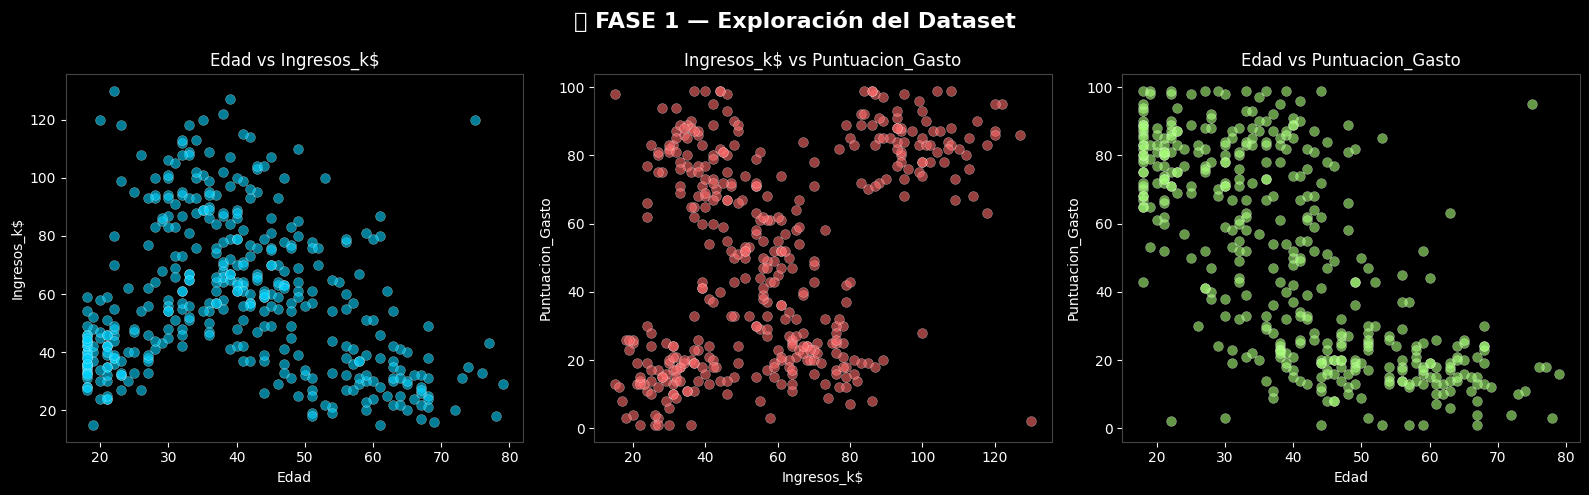

In [43]:
# 📊 Visualización exploratoria — Pairplot de variables
# Muestra la relación entre TODAS las columnas numéricas a la vez

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🔍 FASE 1 — Exploración del Dataset', fontsize=16, fontweight='bold', color='white')

pares = [("Edad", "Ingresos_k$"), ("Ingresos_k$", "Puntuacion_Gasto"), ("Edad", "Puntuacion_Gasto")]
colores = ['#00d4ff', '#ff6b6b', '#a8ff78']

for ax, (x, y), c in zip(axes, pares, colores):
    ax.scatter(df[x], df[y], alpha=0.6, color=c, edgecolors='white', linewidths=0.3, s=50)
    ax.set_xlabel(x, color='white')
    ax.set_ylabel(y, color='white')
    ax.set_title(f'{x} vs {y}', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()


### 💬 ¿Puedes ver ya visualmente algún grupo en los gráficos? 
Anótalo antes de continuar..."   


---

## ⚙️ FASE 2 — Preparar los datos para el algoritmo

### 🧪 Normalización: igualar el terreno de juego

Los algoritmos de clustering miden **distancias** entre puntos. Si una variable tiene valores entre 0-100 y otra entre 15.000-100.000, la segunda dominará el cálculo aunque no sea más importante.

**Solución:** `StandardScaler` — transforma cada variable para que tenga **media 0** y **desviación estándar 1**.

```
Valor original:  Ingresos = 85.000 €
Valor escalado:  Ingresos_scaled ≈ 1.2  ("está 1.2 desviaciones por encima de la media")
```

In [ ]:
# 🔬 Seleccionamos las variables para clustering (las numéricas relevantes)
features = ["Ingresos_k$", "Puntuacion_Gasto"]  

X = df[features].values  # Convertimos a array NumPy

# 📝 RETO: Normalizamos los datos
# 💡 PISTA: Fase 0 
scaler = __________()                  
X_scaled = scaler.fit_transform(X)

print("📏 ANTES de escalar (primeras 5 filas):")
print(pd.DataFrame(X, columns=features).head().to_string(index=False))

print("\n📐 DESPUÉS de escalar (primeras 5 filas):")
print(pd.DataFrame(X_scaled, columns=[f + '_scaled' for f in features]).head().round(3).to_string(index=False))

print("\n✅ Datos preparados para el algoritmo.")

---

## 🤖 FASE 3 — Algoritmo K-Means

### ¿Cómo funciona K-Means? 🧠

```
1. Elige K puntos aleatorios como "centroides" iniciales
2. Asigna cada dato al centroide más cercano → se forman K grupos
3. Recalcula el centroide de cada grupo (la media del grupo)
4. Repite 2-3 hasta que los centroides no se muevan (convergencia)
```

> ⚠️ **Problema:** K-Means necesita que tú le digas cuántos grupos (K) quieres.
> Pero nosotros no sabemos cuántos grupos hay... ¡Para eso existe el **Método del Codo**! 📐

### 🔍 Paso 3a — El Método del Codo (Elbow Method)

Probamos K-Means con distintos valores de K y medimos el **error interno** (llamado inercia o WCSS).
Donde la curva "se dobla" como un codo → ese es el K óptimo.

In [ ]:
# 📐 MÉTODO DEL CODO — ¿Cuántos grupos existen?

inercias = []       # aquí guardaremos el error de cada K
rango_k = range(1, 11)  # probamos K desde 1 hasta 10

for k in rango_k:
    # Creamos un modelo K-Means con k grupos
    # n_init=10 → ejecuta 10 veces con centroides aleatorios distintos y se queda con el mejor
    # random_state=42 → fija la semilla para reproducibilidad
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    modelo.fit(X_scaled)          # entrenamos el modelo
    inercias.append(modelo.inertia_)  # inertia_ = suma de distancias cuadráticas a los centroides

# --- Visualización del Codo ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rango_k, inercias, 'o-', color='#00d4ff', linewidth=2.5, markersize=9, markerfacecolor='white')
ax.set_xlabel('Número de Clusters (K)', color='white', fontsize=12)
ax.set_ylabel('Inercia (WCSS)', color='white', fontsize=12)
ax.set_title('📐 Método del Codo — ¿Dónde está el "codo"?', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(fontsize=11, labelcolor='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

❓ PREGUNTA: ¿En qué valor de K ves el 'codo' de la curva?"   
Ese es el número óptimo de grupos. Escríbelo antes de continuar.   

K óptimo = __

### 🧩 RETO 2 — Coeficiente de Silhouette

El **Coeficiente de Silhouette** es otra forma de validar el número de clusters.

- Mide qué tan "bien separados" están los grupos
- Va de **-1** (pésimo) a **+1** (perfecto) — queremos el valor más alto

> 🎯 ¿Confirma el mismo K que el método del codo?

In [ ]:
# Calcula el Silhouette Score para K = 2 a 10

silhouettes = []
rango_k2 = range(2, 11)  # silhouette no tiene sentido con K=1

for k in rango_k2:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(X_scaled)  # fit + predict en un solo paso
    
    score = silhouette_score(X_scaled, etiquetas)  
    silhouettes.append(score)

# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(rango_k2, silhouettes, color='#a8ff78', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.set_xlabel('Número de Clusters (K)', color='white', fontsize=12)
ax.set_ylabel('Silhouette Score', color='white', fontsize=12)
ax.set_title('🔬 Silhouette Score por número de clusters', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.set_ylim(0, 1)
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

# Destacamos el mejor K
mejor_k = list(rango_k2)[np.argmax(silhouettes)]
ax.bar(mejor_k, max(silhouettes), color='#ff6b6b', edgecolor='white', linewidth=1.5, label=f'Mejor K = {mejor_k}')
ax.legend(fontsize=11, labelcolor='white')

plt.tight_layout()
plt.show()

print(f"\n🏆 El mejor Silhouette Score es {max(silhouettes):.3f} con K = {mejor_k}")

### 🚀 Paso 3b — Ejecutar K-Means con el K óptimo

In [ ]:
#  🚀 K-Means final con K óptimo
#  💡 PISTA: Fase 3
K_OPTIMO = __

kmeans = KMeans(n_clusters=K_OPTIMO, n_init=10, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Los centroides (en escala original, no normalizada)
centroides_scaled = kmeans.cluster_centers_
centroides_original = scaler.inverse_transform(centroides_scaled)
df_centroides = pd.DataFrame(centroides_original, columns=features)
df_centroides.index.name = 'Cluster'

print("📍 POSICIÓN DE LOS CENTROIDES (escala original):")
print(df_centroides.round(1))
print(f"\n🔢 Distribución de clientes por cluster:")
print(df['Cluster_KMeans'].value_counts().sort_index().rename(index=lambda x: f'Cluster {x}'))

In [ ]:
# 🗺️ MAPA DE CLUSTERS — El gran reveal
colores_clusters = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#A8FF78', '#C77DFF', "#3438FA"]
nombres_clusters = [f'Grupo {i}' for i in range(K_OPTIMO)]

fig, ax = plt.subplots(figsize=(11, 7))

for cluster_id in range(K_OPTIMO):
    mask = df['Cluster_KMeans'] == cluster_id
    ax.scatter(
        df.loc[mask, 'Ingresos_k$'],
        df.loc[mask, 'Puntuacion_Gasto'],
        s=70, alpha=0.75,
        color=colores_clusters[cluster_id],
        edgecolors='white', linewidths=0.4,
        label=nombres_clusters[cluster_id]
    )

# Marcamos los centroides
ax.scatter(
    df_centroides['Ingresos_k$'],
    df_centroides['Puntuacion_Gasto'],
    marker='X', s=280, color='white',
    edgecolors='black', linewidths=1.5,
    zorder=5, label='Centroides'
)

ax.set_xlabel('Ingresos Anuales (k$)', color='white', fontsize=12)
ax.set_ylabel('Puntuación de Gasto (1-100)', color='white', fontsize=12)
ax.set_title('🗺️ OPERACIÓN CLUSTER — Grupos Descubiertos (K-Means)', color='white', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, labelcolor='white', framealpha=0.3)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

### 🧩 RETO 3 — Ponerle nombre a los grupos

Un analista de datos no solo encuentra clusters... los **interpreta**.

Ejecuta la siguiente celda para ver el perfil medio de cada grupo y **rellena la tabla**:

In [ ]:
# 📊 Perfil de cada cluster
perfil = df.groupby('Cluster_KMeans')[['Edad', 'Ingresos_k$', 'Puntuacion_Gasto']].mean().round(1)
perfil['N_clientes'] = df.groupby('Cluster_KMeans').size()
print("📊 PERFIL PROMEDIO DE CADA CLUSTER:")
print(perfil.to_string())

✍️ COMPLETA EL DICCIONARIO CON TUS NOMBRES:   
Basándote en los valores de Ingresos y Puntuacion_Gasto,   
asigna un nombre descriptivo a cada cluster.   
   Ejemplos de nombres posibles:   
    - "Alto poder adquisitivo, alto gasto"   
    - "Ingresos bajos, ahorradores"   
    - "Ingresos altos, ahorradores"   
    - "Clase media, gasto moderado"   
    - "Ingresos bajos, alto gasto (impulsivos)"   
    
    Modifica el diccionario de abajo:

In [ ]:
nombres_personalizados = {
    0: "👤 Nombre del Grupo 0",  # ← escribe tu nombre aquí
    1: "👤 Nombre del Grupo 1",
    2: "👤 Nombre del Grupo 2",
    3: "👤 Nombre del Grupo 3",
    4: "👤 Nombre del Grupo 4",
}
print("Tu clasificación:", nombres_personalizados)

---

## 🕵️ FASE 4 — Algoritmo DBSCAN: cazando anomalías

### ¿Por qué K-Means no siempre es suficiente?

K-Means tiene **limitaciones**:
- Asume que los grupos son **esféricos**
- **Todo punto** es asignado a un grupo (aunque sea raro)
- Hay que especificar K de antemano

**DBSCAN** (Density-Based Spatial Clustering) soluciona esto:

```
DBSCAN clasifica cada punto como:
  ● Punto central:  tiene muchos vecinos cerca → núcleo de un cluster
  ○ Punto borde:    está cerca de un punto central → pertenece al cluster
  ✕ Ruido (outlier): está solo, lejos de todos → marcado como -1
```

### Parámetros de DBSCAN:
- `eps`: radio de vecindad — ¿qué tan "cerca" tiene que estar un vecino?
- `min_samples`: mínimo de vecinos para ser un punto central

In [ ]:
# 🕵️ DBSCAN — Detección de grupos y anomalías

# Usamos los 3 features ahora (más información = mejor detección)
X3 = df[["Edad", "Ingresos_k$", "Puntuacion_Gasto"]].values
X3_scaled = StandardScaler().fit_transform(X3)

dbscan = DBSCAN(
    eps=0.6,          # radio de vecindad (en espacio escalado)
    min_samples=5     # mínimo de puntos para ser "zona densa"
)

df['Cluster_DBSCAN'] = dbscan.fit_predict(X3_scaled)
# ⚠️ DBSCAN marca los outliers con -1

# Contamos resultados
conteo = df['Cluster_DBSCAN'].value_counts().sort_index()
print("🔢 RESULTADOS DBSCAN:")
for idx, cnt in conteo.items():
    if idx == -1:
        print(f"  ⚠️  OUTLIERS (ruido):  {cnt} puntos")
    else:
        print(f"  Cluster {idx}:  {cnt} puntos")

# Visualización
# Reducimos a 2D con PCA para poder dibujar los 3 features
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🕵️ DBSCAN vs K-Means — Comparación', fontsize=14, fontweight='bold', color='white')

# K-Means en PCA
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
    c=df['Cluster_KMeans'], cmap='Set1', alpha=0.7, s=50, edgecolors='white', linewidths=0.3)
axes[0].set_title('K-Means (K=5)', color='white', fontsize=12)

# DBSCAN en PCA
colores_db = df['Cluster_DBSCAN'].map(lambda x: '#ff0000' if x == -1 else plt.cm.Set2(x / 5))
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
    c=df['Cluster_DBSCAN'], cmap='Set2', alpha=0.7, s=50, edgecolors='white', linewidths=0.3)

# Marcamos outliers
outlier_mask = df['Cluster_DBSCAN'] == -1
axes[1].scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
    c='red', s=150, marker='X', edgecolors='white', linewidths=1, zorder=5, label='Outliers ⚠️')
axes[1].legend(fontsize=10, labelcolor='white', framealpha=0.3)
axes[1].set_title('DBSCAN — Outliers en rojo', color='white', fontsize=12)

for ax in axes:
    ax.tick_params(colors='white')
    ax.set_xlabel('PCA 1', color='white')
    ax.set_ylabel('PCA 2', color='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

print("\n🔴 Los puntos rojos X son outliers — clientes con perfil atípico.")
print("   ¿Qué tienen de especial? Mira sus valores:")
print(df[df['Cluster_DBSCAN'] == -1][["Edad", "Ingresos_k$", "Puntuacion_Gasto"]])

---

## 📊 FASE 5 — Dashboard de resultados

Un agente entrega un **informe visual** de sus descubrimientos. Generemos el dashboard final:

In [ ]:
# 🗂️ DASHBOARD FINAL — Resumen de la misión

fig = plt.figure(figsize=(18, 12))
fig.suptitle('📊 OPERACIÓN CLUSTER — Informe Final de la Misión', 
             fontsize=17, fontweight='bold', color='white', y=0.98)

# ── Panel 1: Scatter Ingresos vs Gasto coloreado por cluster ──
ax1 = fig.add_subplot(2, 3, 1)
for cid in range(K_OPTIMO):
    m = df['Cluster_KMeans'] == cid
    ax1.scatter(df.loc[m,'Ingresos_k$'], df.loc[m,'Puntuacion_Gasto'],
                color=colores_clusters[cid], s=40, alpha=0.7, edgecolors='white', linewidths=0.2)
ax1.scatter(df_centroides['Ingresos_k$'], df_centroides['Puntuacion_Gasto'],
            marker='X', s=180, c='white', zorder=5)
ax1.set_title('Ingresos vs Gasto', color='white', fontsize=10)
ax1.set_xlabel('Ingresos (k$)', color='white', fontsize=8)
ax1.set_ylabel('Puntuación Gasto', color='white', fontsize=8)

# ── Panel 2: Scatter Edad vs Gasto ──
ax2 = fig.add_subplot(2, 3, 2)
for cid in range(K_OPTIMO):
    m = df['Cluster_KMeans'] == cid
    ax2.scatter(df.loc[m,'Edad'], df.loc[m,'Puntuacion_Gasto'],
                color=colores_clusters[cid], s=40, alpha=0.7, edgecolors='white', linewidths=0.2)
ax2.set_title('Edad vs Gasto', color='white', fontsize=10)
ax2.set_xlabel('Edad', color='white', fontsize=8)
ax2.set_ylabel('Puntuación Gasto', color='white', fontsize=8)

# ── Panel 3: Distribución de tamaño de clusters ──
ax3 = fig.add_subplot(2, 3, 3)
sizes = df['Cluster_KMeans'].value_counts().sort_index()
bars = ax3.bar(range(K_OPTIMO), sizes.values, color=colores_clusters, edgecolor='white', linewidth=0.5)
ax3.set_title('Tamaño de cada Cluster', color='white', fontsize=10)
ax3.set_xlabel('Cluster', color='white', fontsize=8)
ax3.set_ylabel('Nº clientes', color='white', fontsize=8)
ax3.set_xticks(range(K_OPTIMO))

# ── Panel 4: Boxplot de Ingresos por cluster ──
ax4 = fig.add_subplot(2, 3, 4)
data_box = [df[df['Cluster_KMeans']==cid]['Ingresos_k$'].values for cid in range(K_OPTIMO)]
bp = ax4.boxplot(data_box, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colores_clusters):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Ingresos por Cluster', color='white', fontsize=10)
ax4.set_xlabel('Cluster', color='white', fontsize=8)
ax4.set_ylabel('Ingresos (k$)', color='white', fontsize=8)

# ── Panel 5: Boxplot de Gasto por cluster ──
ax5 = fig.add_subplot(2, 3, 5)
data_box2 = [df[df['Cluster_KMeans']==cid]['Puntuacion_Gasto'].values for cid in range(K_OPTIMO)]
bp2 = ax5.boxplot(data_box2, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp2['boxes'], colores_clusters):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_title('Gasto por Cluster', color='white', fontsize=10)
ax5.set_xlabel('Cluster', color='white', fontsize=8)
ax5.set_ylabel('Puntuación Gasto', color='white', fontsize=8)

# ── Panel 6: Radar / Heatmap de perfiles ──
ax6 = fig.add_subplot(2, 3, 6)
perfil_heatmap = df.groupby('Cluster_KMeans')[['Edad','Ingresos_k$','Puntuacion_Gasto']].mean()
perfil_norm = (perfil_heatmap - perfil_heatmap.min()) / (perfil_heatmap.max() - perfil_heatmap.min())
sns.heatmap(perfil_norm, annot=perfil_heatmap.round(0).astype(int), fmt='d',
            cmap='RdYlGn', ax=ax6, linewidths=0.5, linecolor='#333',
            cbar_kws={'shrink': 0.7})
ax6.set_title('Heatmap de Perfiles', color='white', fontsize=10)
ax6.set_xlabel('Variable', color='white', fontsize=8)
ax6.set_ylabel('Cluster', color='white', fontsize=8)
ax6.tick_params(colors='white')

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

---

## 🧩 RETO FINAL — Informe de Misión Completado

Rellena el siguiente informe. Puedes modificar el texto directamente en esta celda Markdown.

---

### 📄 INFORME AID — Clasificación: SECRETO

**Agente:** *(escribe tu nombre aquí)*

**Fecha:** *(fecha de hoy)*

---

#### 1. Número de grupos descubiertos
Con K-Means, el número óptimo de grupos es **K = ?**

Lo determiné usando el **Método del ___** y confirmé con el **Coeficiente de ___**.

---

#### 2. Descripción de los grupos

| Cluster | Nombre asignado | Ingresos | Puntuación Gasto | Recomendación de marketing |
|---------|----------------|----------|-----------------|---------------------------|
| 0 | | | | |
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |

---

#### 3. Anomalías detectadas (DBSCAN)

DBSCAN detectó **? outliers**. Estos clientes son especiales porque...

---

#### 4. Reflexión

¿Cuándo usarías K-Means y cuándo DBSCAN? *(mínimo 3 líneas)*

---

### 🏆 MISIÓN COMPLETADA

> *"Los datos nunca mienten... si sabes cómo escucharlos."*
>
> — Agencia Internacional de Datos

---

## 🎓 BONUS TRACK — Para los agentes más avanzados

Si has completado la misión principal y quieres más, aquí van retos extra:

### 🌟 Bonus 1 — Clustering jerárquico (Dendrograma)
Investiga `scipy.cluster.hierarchy.dendrogram` y úsalo con este dataset. ¿Cuántos grupos sugiere?

### 🌟 Bonus 2 — Repite con los 3 features
Hasta ahora K-Means usó solo `Ingresos_k$` y `Puntuacion_Gasto`. Repite el análisis incluyendo `Edad`. ¿Cambian los grupos?

### 🌟 Bonus 3 — Datos reales
Descarga el dataset original "Mall Customer Segmentation" desde [Kaggle](https://www.kaggle.com/vjchoudhary7/customer-segmentation-tutorial-in-python) y aplica el mismo pipeline.

### 🌟 Bonus 4 — Ajuste de DBSCAN
Experimenta con distintos valores de `eps` y `min_samples`. ¿Cómo cambian los clusters y el número de outliers? Usa `eps` entre 0.3 y 1.2.

In [ ]:
# 🌟 BONUS 1 — Dendrograma (clustering jerárquico)
from scipy.cluster.hierarchy import dendrogram, linkage

# Usamos una muestra de 50 puntos para que el dendrograma sea legible
muestra = X_scaled[:50]

# 'ward' minimiza la varianza dentro de los clusters
Z = linkage(muestra, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, color_threshold=3.5,
           above_threshold_color='white',
           leaf_rotation=90, leaf_font_size=8)
ax.set_title('🌳 Dendrograma — Clustering Jerárquico', color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Muestras', color='white')
ax.set_ylabel('Distancia (Ward)', color='white')
ax.tick_params(colors='white')
ax.axhline(y=3.5, color='#ff6b6b', linestyle='--', linewidth=2, label='Corte sugerido → ~5 grupos')
ax.legend(labelcolor='white', framealpha=0.3)
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.show()

print("\n💡 Cada 'rama' del árbol que cortas con la línea roja = un cluster.")
print("   Las ramas más largas = grupos más diferentes entre sí.")